# Script that renders the images which are then fed to the digitization script.

In [ ]:
import matplotlib.pyplot as plt
COMMON_X = np.arange(552, 3844, 2.0, dtype=np.float32)

# create the directory (only once)
os.makedirs("./plot_imgs", exist_ok=True)
data_test = pd.read_parquet('../../data/test.parquet')
data_test_sdbs = data_test[data_test['source_name'] == "sdbs"]
# ---------- key change: draw 1000 spectra at once (without replacement) ----------
sampled_df = data_test_sdbs.sample(n=1000, replace=False)  # replace=False guarantees no duplicates

for i, (idx, row) in enumerate(sampled_df.iterrows()):
    test_compound = row['sample_id']
    spectrum = row['spectrum']
    
    # optional: check the spectrum length to avoid plotting errors
    if len(spectrum) != len(COMMON_X):
        print(f"WARNING: spectrum {i} has a mismatched length, skipping: {test_compound}")
        continue
    
    plt.figure(figsize=(10, 6))
    plt.plot(COMMON_X, spectrum, label=f'{test_compound}')
    plt.xlim(552, 3844)
    plt.xlabel('Wavenumber (cm⁻¹)')
    plt.ylabel('Intensity')
    plt.legend(loc='upper right')
    plt.tight_layout()
    
    # sanitise the file name (remove illegal characters)
    plt.savefig(f"./plot_imgs/{i:04d}_{test_compound}.png", dpi=600)
    plt.close()
    
    print(f'OK {i+1}/1000 done')

In [ ]:
import numpy as np
def spectral_metrics(y_true, y_pred):
    # 1. RMSE
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    
    # 2. coefficient of determination R2 (measures absolute fit, affected by the baseline)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2_score = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    return {
        "RMSE": rmse,
        "R2": r2_score,
    }

# Plot the digitized_results.json produced from the rendered images.

/tmp/ipykernel_2062709/936039395.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


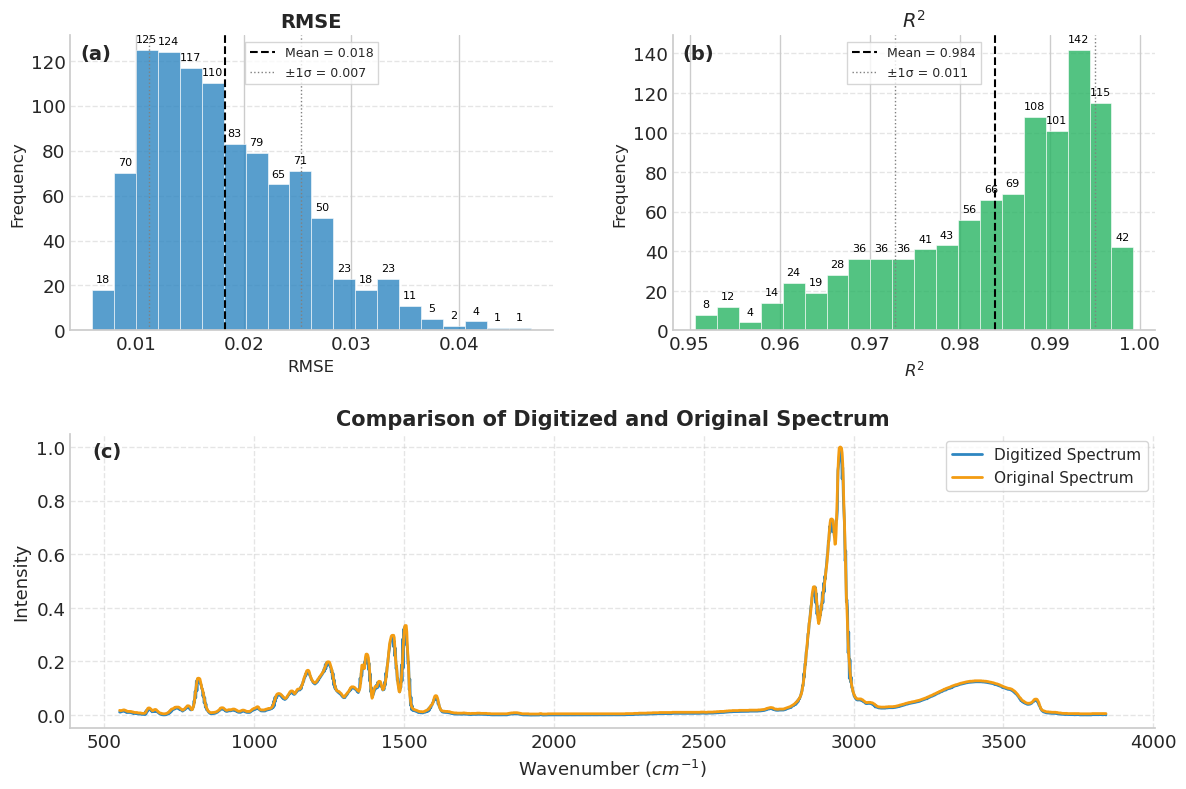

In [68]:
# interpolate onto common_x
import pandas as pd
from scipy.interpolate import CubicSpline
import json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import seaborn as sns

# ---------------------- load the data ----------------------
with open("digitized_results.json", "r") as f:
    data_200 = json.load(f)
data_row = pd.read_parquet('../../data/all.parquet')

COMMON_X = np.arange(552, 3844, 2.0, dtype=np.float32)

rmse_list, R2_list, R2_P_list, SAM_list = [], [], [], []
test_df_digital = {"spectrum": [], 'sample_id': []}

plot_sample_x = None
plot_y_digitized = None
plot_y_original = None

for index, (spec_id, item) in enumerate(data_200.items()):
    spec_id = spec_id.split('_')[1]
    x_digital = np.array(item['x'])
    y_digital = np.array(item['y'])
    y_digital_norm = (y_digital - np.min(y_digital)) / (np.max(y_digital) - np.min(y_digital))
    cs = CubicSpline(np.linspace(552, 3844, len(x_digital)), y_digital_norm,
                     bc_type='natural', extrapolate=True)
    y_interp = cs(COMMON_X)

    test_df_digital['spectrum'].append(y_interp)
    test_df_digital['sample_id'].append(spec_id)

    row = data_row[data_row['sample_id'] == spec_id]
    if row.empty:
        print(f"WARNING: no reference spectrum found for {spec_id}, skipping")
        continue
    y_row_raw = np.array(row.iloc[0]['spectrum'])
    metrics = spectral_metrics(y_row_raw, y_interp)

    rmse_list.append(metrics["RMSE"])
    R2_list.append(metrics["R2"])

    if plot_sample_x is None:
        plot_sample_x = COMMON_X
        plot_y_digitized = y_interp
        plot_y_original = y_row_raw


# ---------------------- histogram plotting helper ----------------------
def plot_hist(ax, data, title, xlabel, ylabel, color):
    counts, bins, patches = ax.hist(data, bins=20, edgecolor='white',
                                     alpha=0.8, color=color, linewidth=0.5)
    for count, patch in zip(counts, patches):
        if count > 0:
            x_pos = patch.get_x() + patch.get_width() / 2
            y_pos = patch.get_height()
            offset = 0.02 * (max(counts) - min(counts)) if max(counts) > min(counts) else 0.5
            ax.text(x_pos, y_pos + offset, f'{int(count)}',
                    ha='center', va='bottom', fontsize=8, color='black')
    mean_val = np.mean(data)
    std_val = np.std(data)
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.5,
               label=f'Mean = {mean_val:.3f}')
    ax.axvline(mean_val - std_val, color='gray', linestyle=':', linewidth=1)
    ax.axvline(mean_val + std_val, color='gray', linestyle=':', linewidth=1,
               label=f'±1σ = {std_val:.3f}')
    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='in', which='both', top=False, right=False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper center', fontsize=9, frameon=True, fancybox=False)


# ---------------------- GridSpec layout: 2 rows x 2 columns ----------------------
sns.set_theme(style="whitegrid", font_scale=1.2)
fig = plt.figure(figsize=(14, 9))          # height changed from 12 to 9, one row fewer
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.25)

ax00 = fig.add_subplot(gs[0, 0])   # (a) RMSE
ax01 = fig.add_subplot(gs[0, 1])   # (b) R²
ax5  = fig.add_subplot(gs[1, :])   # (c) spectrum comparison (spans the whole row)

plot_hist(ax00, rmse_list, 'RMSE',                       'RMSE',             'Frequency', '#2E86C1')
plot_hist(ax01, R2_list,   r'$R^2$', r'$R^2$', 'Frequency', '#28B463')

# spectrum comparison panel
ax5.plot(plot_sample_x, plot_y_digitized, color='#2E86C1', label="Digitized Spectrum", linewidth=2)
ax5.plot(plot_sample_x, plot_y_original,  color='#F39C12', label="Original Spectrum",  linewidth=2)
ax5.set_title("Comparison of Digitized and Original Spectrum", fontsize=15, weight='bold')
ax5.set_xlabel(r'Wavenumber ($cm^{-1}$)', fontsize=13)
ax5.set_ylabel("Intensity", fontsize=13)
ax5.legend(loc='upper right', fontsize=11, frameon=True)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.tick_params(direction='in', which='both')
ax5.grid(True, linestyle='--', alpha=0.5)

# ============ renumber a / b / c ============
anno_list = [
    (ax00, "(a)"),
    (ax01, "(b)"),
    (ax5,  "(c)"),
]
for ax, label in anno_list:
    ax.text(0.02, 0.97, label, transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.savefig('spectral_metrics_histograms_3panel.png', dpi=600, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()